In [26]:
import numpy as np
import pandas as pd

def add_features(X):
    # We use .copy() to ensure that the original DataFrame X is not changed.
    X = X.copy()

    # =========================
    # 1) Basic Structural Features
    # =========================
    # Calculate the current age of the house. (Assuming the current year is 2025)
    X["House_Age"] = 2025 - X["Year_Built"]

    # Total rooms (number of bedrooms + number of bathrooms)
    X["Total_Rooms"] = X["Num_Bedrooms"] + X["Num_Bathrooms"]

    # The ratio of the number of bedrooms to the number of bathrooms.
    # We use np.where to avoid division by zero (in the case of Num_Bathrooms = 0), and in this case, we use NaN.
    X["Bed_Bath_Ratio"] = np.where(
        X["Num_Bathrooms"] > 0,
        X["Num_Bedrooms"] / X["Num_Bathrooms"],
        np.nan
    )

    # Lot size conversion: Convert Lot_Size (in acres) to square meters (sqm).
    X["Lot_Size_sqm"] = X["Lot_Size"] * 4046.8564224

    # Rooms Density: (Total Rooms / Square Footage).
    # Measures how 'crowded' the rooms are within the area. np.where avoids division by zero.
    X["Rooms_Density"] = np.where(
        X["Square_Footage"] > 0,
        X["Total_Rooms"] / X["Square_Footage"],
        np.nan
    )

    # Ratio of garage size (car capacity) to total rooms.
    X["Garage_per_Room"] = np.where(
        X["Total_Rooms"] > 0,
        X["Garage_Size"] / X["Total_Rooms"],
        np.nan
    )

    # Neighborhood Size Index: (Neighborhood Quality * Square Footage).
    # Combines the size of the house with the surrounding neighborhood quality.
    X["Neighborhood_Size"] = X["Neighborhood_Quality"] * X["Square_Footage"]

    # Structural Value Index: (Square Footage * Quality) divided by Total Rooms.
    # Measures the efficiency of space utilization given the neighborhood quality.
    X["Structural_Value_Index"] = np.where(
        X["Total_Rooms"] > 0,
        (X["Square_Footage"] * X["Neighborhood_Quality"]) / X["Total_Rooms"],
        np.nan
    )

    # Luxury Index: (Garage Size + Number of Bathrooms) * Neighborhood Quality.
    # Focuses on high-value, comfort features of the property and area.
    X["Luxury_Index"] = (X["Garage_Size"] + X["Num_Bathrooms"]) * X["Neighborhood_Quality"]

    # Price Size Estimate: A rough price estimation based on size and quality, using a baseline price of $120/sqft.
    X["Price_Size_Estimate"] = X["Square_Footage"] * X["Neighborhood_Quality"] * 120

    # Land Value Ratio: Ratio of the Lot Size (sqm) to the house's Square Footage.
    # Measures the size of the surrounding land relative to the house footprint.
    X["Land_Value_Ratio"] = np.where(
        X["Square_Footage"] > 0,
        X["Lot_Size_sqm"] / X["Square_Footage"],
        np.nan
    )

    # Age Decay Factor: A non-linear factor to diminish value based on house age: (1 / (1 + House Age)).
    X["Age_Decay_Factor"] = 1 / (1 + X["House_Age"])

    # Modern Ratio: Ratio of modern amenities (Garage + Bathrooms) to the house's Age.
    X["Modern_Ratio"] = np.where(
        X["House_Age"] > 0,
        (X["Garage_Size"] + X["Num_Bathrooms"]) / X["House_Age"],
        np.nan
    )

    # Neighborhood Space Index: Neighborhood Quality multiplied by the natural logarithm of Square Footage (log1p).
    # Log transformation reduces the impact of extreme outliers in large areas.
    X["Neighborhood_Space_Index"] = X["Neighborhood_Quality"] * np.log1p(X["Square_Footage"])

    return X

In [27]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

X_train_processed = np.load("X_train_processed.npy")
X_val_processed = np.load("X_val_processed.npy")

y_train = pd.read_csv("y_train.csv").squeeze()
y_val = pd.read_csv("y_val.csv").squeeze()

preprocess_pipeline = joblib.load("preprocessing_pipeline.joblib")

print(f"Training data (X): {X_train_processed.shape}")

Training data (X): (640, 21)


In [28]:
lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_val_lr = lr_model.predict(X_val_processed)

In [29]:
mae_lr = mean_absolute_error(y_val, y_pred_val_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_val_lr))
r2_lr = r2_score(y_val, y_pred_val_lr)

print("\nPerformance evaluation of the Linear Regression model:")
print(f"Mean Absolute Error (MAE): ${mae_lr:,.2f}") #Average error in dollars
print(f"Root Mean Squared Error (RMSE): ${rmse_lr:,.2f}")
print(f"R-squared (R2 Score): {r2_lr:.4f}") # The closer the value is to 1.0, the better the model.


Performance evaluation of the Linear Regression model:
Mean Absolute Error (MAE): $7,022.70
Root Mean Squared Error (RMSE): $8,868.68
R-squared (R2 Score): 0.9988


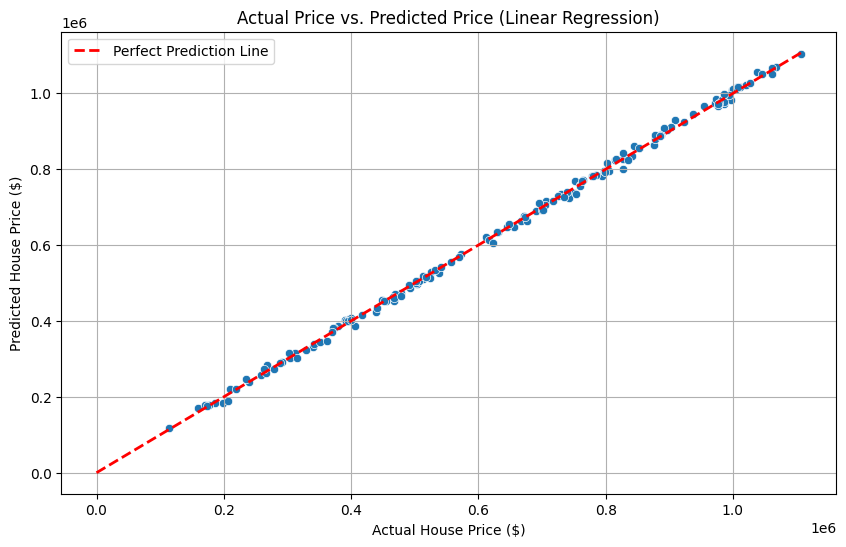

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_val, y=y_pred_val_lr)

max_val = max(y_val.max(), y_pred_val_lr.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual Price vs. Predicted Price (Linear Regression)')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Predicted House Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
X_test_raw = pd.read_csv("X_test_raw.csv")
y_test = pd.read_csv("y_test.csv").squeeze()


X_test_processed = preprocess_pipeline.transform(X_test_raw)

y_pred_test = lr_model.predict(X_test_processed)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\nFinal Performance Assessment (Test Set):")
print(f"Mean Absolute Error (MAE): ${mae_test:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_test:,.2f}")
print(f"R-squared (R2 Score): {r2_test:.4f}")


Final Performance Assessment (Test Set):
Mean Absolute Error (MAE): $8,138.30
Root Mean Squared Error (RMSE): $10,116.65
R-squared (R2 Score): 0.9984
